In [20]:
%pip install matplotlib

40.85s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


You should consider upgrading via the '/Users/vidushi/Desktop/Web development/pudding article chess/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [21]:
import sys
print(sys.executable)


/Users/vidushi/Desktop/Web development/pudding article chess/.venv/bin/python


# Chess Improvement Analysis – Data Preparation

This notebook prepares a Lichess game dataset so we can study how different players
improve over their first 93 games.

**Goal**

- Build a *player-centric* dataset (one row = one player in one game).
- Find players who:
  - Reach **800–900** rating by their 93rd game (fast improvers).
  - Plateau around **500–600** rating by their 93rd game (slow/plateau group).
- Once these groups are identified, we will later analyze:
  - Act 1: Rating progression and opponents faced.
  - Act 2: Where they gain rating points (opening, middlegame, endgame).
  - Act 3: Adaptability when out of book.

This first section is only about **loading, cleaning, and restructuring** the data.

In [22]:
import matplotlib.pyplot as plt

In [23]:
import pandas as pd
import numpy as np

print("OK:", pd.__version__)

OK: 2.3.3


In [24]:
import pandas as pd

df = pd.read_csv("/Users/vidushi/Downloads/chess_games.csv")
df.head()


,game_id,rated,turns,victory_status,winner,time_increment,white_id,white_rating,black_id,black_rating,moves,opening_code,opening_moves,opening_fullname,opening_shortname,opening_response,opening_variation
0,1,False,13,Out of Time,White,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,5,Slav Defense: Exchange Variation,Slav Defense,NaN,Exchange Variation
1,2,True,16,Resign,Black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,4,Nimzowitsch Defense: Kennedy Variation,Nimzowitsch Defense,NaN,Kennedy Variation
2,3,True,61,Mate,White,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,3,King's Pawn Game: Leonardis Variation,King's Pawn Game,NaN,Leonardis Variation
3,4,True,61,Mate,White,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,3,Queen's Pawn Game: Zukertort Variation,Queen's Pawn Game,NaN,Zukertort Variation
4,5,True,95,Mate,White,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,5,Philidor Defense,Philidor Defense,NaN,NaN


In [25]:
unique_white = df["white_id"].nunique()
unique_black = df["black_id"].nunique()

# Total unique players (union of both columns)
unique_players = pd.unique(df[["white_id", "black_id"]].values.ravel())

len(unique_players), unique_white, unique_black


(15635, 9438, 9331)

## Step 2 – Filter to **rated** games only

We are interested in **rating improvement**, so we only want games where the rating
actually changes.

The column:
- `rated` is a boolean (True/False) indicating whether the game was rated.

We:
1. Keep only rows where `rated == True`.
2. Reset the index so row numbers are clean after filtering.

In [26]:
df = df[df["rated"] == True]
df = df.reset_index(drop=True)

## Step 3 – Ensure rating columns are numeric

Sometimes CSVs store numbers as text. We want `white_rating` and `black_rating` to be
numeric so we can compare, sort, and compute with them.

We:
1. Convert `white_rating` and `black_rating` to numeric.
2. Drop any rows where the conversion failed (e.g., missing or invalid values).

In [27]:
df["white_rating"] = pd.to_numeric(df["white_rating"], errors="coerce")
df["black_rating"] = pd.to_numeric(df["black_rating"], errors="coerce")

df = df.dropna(subset=["white_rating", "black_rating"]).copy()
df.head()


,game_id,rated,turns,victory_status,winner,time_increment,white_id,white_rating,black_id,black_rating,moves,opening_code,opening_moves,opening_fullname,opening_shortname,opening_response,opening_variation
0,2,True,16,Resign,Black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,4,Nimzowitsch Defense: Kennedy Variation,Nimzowitsch Defense,NaN,Kennedy Variation
1,3,True,61,Mate,White,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,3,King's Pawn Game: Leonardis Variation,King's Pawn Game,NaN,Leonardis Variation
2,4,True,61,Mate,White,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,3,Queen's Pawn Game: Zukertort Variation,Queen's Pawn Game,NaN,Zukertort Variation
3,5,True,95,Mate,White,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,5,Philidor Defense,Philidor Defense,NaN,NaN
4,7,True,33,Resign,White,10+0,capa_jr,1520,daniel_likes_chess,1423,d4 d5 e4 dxe4 Nc3 Nf6 f3 exf3 Nxf3 Nc6 Bb5 a6 ...,D00,10,Blackmar-Diemer Gambit: Pietrowsky Defense,Blackmar-Diemer Gambit,NaN,Pietrowsky Defense


## Step 4 – Convert from "game-centric" to "player-centric"

The original dataset has one row **per game** with both white and black information.

For our analysis we want one row **per player per game**, because:
- We want to follow individual players over time.
- A single player appears as both white and black in different games.

We do this in two sub-steps:

1. Create a table for the **white** player in each game.
2. Create a table for the **black** player in each game.
3. Stack (concatenate) those two tables into one big `games` DataFrame.

New unified columns:
- `player_id` – the username (white_id or black_id)
- `player_rating` – rating at the start of the game
- `opponent_rating` – rating of the opponent
- `color` – 'white' or 'black'


In [28]:
# White-player rows
white_df = df[[
    "game_id",
    "white_id",
    "white_rating",
    "black_rating",
    "opening_code",
    "opening_moves",
    "opening_fullname",
    "moves",
    "winner"          # <-- added
]].copy()

white_df = white_df.rename(columns={
    "white_id": "player_id",
    "white_rating": "player_rating",
    "black_rating": "opponent_rating"
})

white_df["color"] = "white"


# Black-player rows
black_df = df[[
    "game_id",
    "black_id",
    "black_rating",
    "white_rating",
    "opening_code",
    "opening_moves",
    "opening_fullname",
    "moves",
    "winner"          # <-- added
]].copy()

black_df = black_df.rename(columns={
    "black_id": "player_id",
    "black_rating": "player_rating",
    "white_rating": "opponent_rating"
})

black_df["color"] = "black"


# Combine white and black views
games = pd.concat([white_df, black_df], ignore_index=True)
games = games.dropna(subset=["player_id"]).copy()
games.head()



,game_id,player_id,player_rating,opponent_rating,opening_code,opening_moves,opening_fullname,moves,winner,color
0,2,a-00,1322,1261,B00,4,Nimzowitsch Defense: Kennedy Variation,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,Black,white
1,3,ischia,1496,1500,C20,3,King's Pawn Game: Leonardis Variation,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,White,white
2,4,daniamurashov,1439,1454,D02,3,Queen's Pawn Game: Zukertort Variation,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,White,white
3,5,nik221107,1523,1469,C41,5,Philidor Defense,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,White,white
4,7,capa_jr,1520,1423,D00,10,Blackmar-Diemer Gambit: Pietrowsky Defense,d4 d5 e4 dxe4 Nc3 Nf6 f3 exf3 Nxf3 Nc6 Bb5 a6 ...,White,white


## Step 5 – Order each player's games and number them

To analyze improvement, we need to know **which game is 1st, 2nd, ..., 93rd** for a player.

We:
1. Sort the `games` table by `player_id` and `game_id`.
2. Within each player group, create a `game_number` column:
   - 1 for their first game in the dataset,
   - 2 for the second, etc.

Note: this uses `game_id` as a proxy for time. It does not guarantee the absolute
first game in their life, but it gives a consistent ordering within this dataset.


In [29]:
games = games.sort_values(by=["player_id", "game_id"]).copy()
games["game_number"] = games.groupby("player_id").cumcount() + 1

games.head()

,game_id,player_id,player_rating,opponent_rating,opening_code,opening_moves,opening_fullname,moves,winner,color,game_number
8140,10139,--jim--,986,1289,B01,2,Scandinavian Defense,e4 d5 Nc3 d4 Nd5 Nf6 Nf3 Nxe4 Bb5+ c6 Bxc6+ Nx...,Black,white,1
26166,12540,-0olo0-,1860,2213,C00,3,French Defense: Normal Variation,e4 e6 d4 c6 Nc3 d5 exd5 exd5 Bd3 Be6 Nf3 Bb4 B...,White,black,1
7849,9789,-l-_jedi_knight_-l-,1465,1416,B00,4,Guatemala Defense,e4 b6 d4 Ba6 Bxa6 Nxa6 Ne2 c5 d5 e6 d6 Nf6 e5 ...,White,white,1
24005,9790,-l-_jedi_knight_-l-,1436,1426,A00,2,Hungarian Opening: Indian Defense,g3 Nf6 Bg2 d5 d3 c6 Bg5 Nfd7 Nc3 h6 Be3 e5 Bd2...,Black,black,2
7851,9791,-l-_jedi_knight_-l-,1473,1414,B00,2,Owen Defense,e4 b6 Ne2 Bb7 d3 Nf6 h3 e6 Be3 Bc5 d4 Bb4+ c3 ...,Black,white,3


## Step 6 – Filter players who have at least 30 games

We are interested in comparing players over their *first 30 games*.

To do this fairly, we:
- Keep only players who appear in the dataset **at least 93 times**.
- Drop players with fewer games (we can't see their 93rd game).

We use `groupby().filter()` to keep only those player groups with length ≥ 93.

In [30]:
N_GAMES = 30   # ← set number of games to analyze

eligible = games.groupby("player_id").filter(lambda x: len(x) >= N_GAMES).copy()

eligible["game_number"].max(), eligible["player_id"].nunique()


(np.int64(96), 192)

## Step 7 – Create a table of only the first 30 games per player

Now we restrict the data to *only* each player's first 30 games.

This gives us a clean dataset where:
- Every row = a player in a particular game.
- Every player has exactly 93 rows (games 1–93).

In [31]:
firstN = eligible[eligible["game_number"] <= N_GAMES].copy()
firstN.head()

,game_id,player_id,player_rating,opponent_rating,opening_code,opening_moves,opening_fullname,moves,winner,color,game_number
7860,9800,1240100948,1700,1675,D00,4,Queen's Pawn Game: Steinitz Countergambit,d4 d5 Bf4 c5 dxc5 Qa5+ Nd2 e6 e3 Nc6 Nf3 Bxc5 ...,Black,white,1
7861,9801,1240100948,1711,1652,D00,3,Queen's Pawn Game: Mason Attack,d4 d5 Bf4 Nf6 e3 Bg4 Be2 Bf5 h3 e6 Nf3 Bd6 Bxd...,Black,white,2
7862,9802,1240100948,1722,1723,D00,3,Queen's Pawn Game: Mason Attack,d4 d5 Bf4 e6 e3 b6 Nf3 Bb7 Bb5+ c6 Be2 Nf6 h3 ...,Black,white,3
24018,9803,1240100948,1710,1734,B40,4,Sicilian Defense: French Variation,e4 c5 Nf3 e6 d4 Nf6 Nc3 d6 Bg5 Be7 dxc5 dxc5 e...,Black,black,4
7864,9804,1240100948,1704,1551,A45,2,Indian Game,d4 Nf6 h3 d5 Bf4 e6 e3 c5 dxc5 Bxc5 a3 O-O Nf3...,White,white,5


## Step 8 – Define fast improvers vs plateau players

We want two groups:

- **Fast improvers**: players who reach **≥ 800 rating** by their 30rd game.
- **Plateau players**: players who are still **≤ 600 rating** by their 30rd game.

Steps:
1. Look at `game_number == 30` for each player.
2. Record their `player_rating` at that game.
3. Use these thresholds to classify player IDs into two lists.
4. (Optional) Take the first 10 from each list for our final sample.

This gives us the 2 groups we'll compare in the later Acts.


In [32]:
# Ratings at game 30 for each player
rating_at_N = firstN[firstN["game_number"] == N_GAMES][["player_id", "player_rating"]].copy()

# Use quartiles (top 25% vs bottom 25%) instead of fixed 800 / 600 cutoffs
q1 = rating_at_N["player_rating"].quantile(0.25)   # bottom 25% cutoff
q3 = rating_at_N["player_rating"].quantile(0.75)   # top 25% cutoff

print("Q1 (bottom 25% rating):", q1)
print("Q3 (top 25% rating):", q3)

# Plateau players = bottom 25% at game 30
plateau_players = rating_at_N[rating_at_N["player_rating"] <= q1]["player_id"].tolist()

# Fast improvers = top 25% at game 30
fast_players = rating_at_N[rating_at_N["player_rating"] >= q3]["player_id"].tolist()

len(fast_players), len(plateau_players)



Q1 (bottom 25% rating): 1378.0
Q3 (top 25% rating): 1790.0


(48, 48)

### Step 9 — Define Final Fast and Plateau Player Groups

After identifying the top 25% (fast improvers) and bottom 25% (plateau players) by
their rating at game 30, we now finalize the two groups we will analyze.

- **fast_group** contains all players whose rating falls in the top quartile.
- **plateau_group** contains all players whose rating falls in the bottom quartile.

These lists store only the player IDs.  
In the next step, we will extract each player’s full 30-game history for analysis.


In [33]:
fast_group = fast_players
plateau_group = plateau_players


### Step 10 — Extract the First 30 Games for Fast and Plateau Players

Now that the groups are defined, we build the final datasets used in all analyses
(Act 1–Act 3).  

- `firstN` contains the first 30 games for every eligible player.
- We filter this table to keep only rows where the `player_id` belongs to one
  of our two groups.

This produces two clean DataFrames:

- **fast_df** → first 30 games of all fast improvers  
- **plateau_df** → first 30 games of all plateau players  

These datasets form the foundation for rating trajectory plots,
opening patterns, and adaptability analysis in later sections.


In [34]:
fast_df = firstN[firstN["player_id"].isin(fast_group)].copy()
plateau_df = firstN[firstN["player_id"].isin(plateau_group)].copy()

## Act 1 — Game Outcome Grid (First 30 Matches)

To mirror the block-based visualization style seen in media analytics (e.g., episode maps),
each player's first 30 games are represented as a sequence of colored squares:

- **Blue = Win**
- **Red = Loss**
- **Green = Draw**

Each row corresponds to one player.
Each column corresponds to Game 1 → Game 30.

This grid allows us to quickly compare the volatility, streaks, and consistency patterns
between the **Fast Improvers** and **Plateau Players**.

A dense concentration of blue blocks early on may signal rapid skill growth, while mixed
or unstable patterns can indicate plateau behavior. The grid provides a clear visual
foundation for understanding early performance trajectories before deeper analysis in
Acts 2 and 3.


In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Make sure winner/colour comparisons aren't broken by capitalization
def outcome(row):
    w = str(row["winner"]).lower().strip()   # who won the game
    c = str(row["color"]).lower().strip()    # this player's colour

    if w == c:
        return "win"
    elif w == "draw":
        return "draw"
    else:
        return "loss"

# Overwrite / create result column for both groups
fast_df["result"] = fast_df.apply(outcome, axis=1)
plateau_df["result"] = plateau_df.apply(outcome, axis=1)

print("Fast group result counts:")
print(fast_df["result"].value_counts())
print("\nPlateau group result counts:")
print(plateau_df["result"].value_counts())


Fast group result counts:
result
win     825
loss    542
draw     73
Name: count, dtype: int64

Plateau group result counts:
result
loss    863
win     526
draw     51
Name: count, dtype: int64


In [36]:
from matplotlib.colors import ListedColormap

N_GAMES = 30  # we’re still using first 30 games

# Map result → integer
result_to_int = {"win": 0, "loss": 1, "draw": 2}

def make_outcome_matrix(df):
    players = sorted(df["player_id"].unique())
    n_players = len(players)
    matrix = np.zeros((n_players, N_GAMES), dtype=int)

    for i, p in enumerate(players):
        subset = df[df["player_id"] == p].sort_values("game_number")
        results = subset["result"].tolist()
        # convert to ints
        int_results = [result_to_int[r] for r in results]
        matrix[i, :len(int_results)] = int_results

    return players, matrix

fast_players_list, fast_matrix = make_outcome_matrix(fast_df)
plateau_players_list, plateau_matrix = make_outcome_matrix(plateau_df)

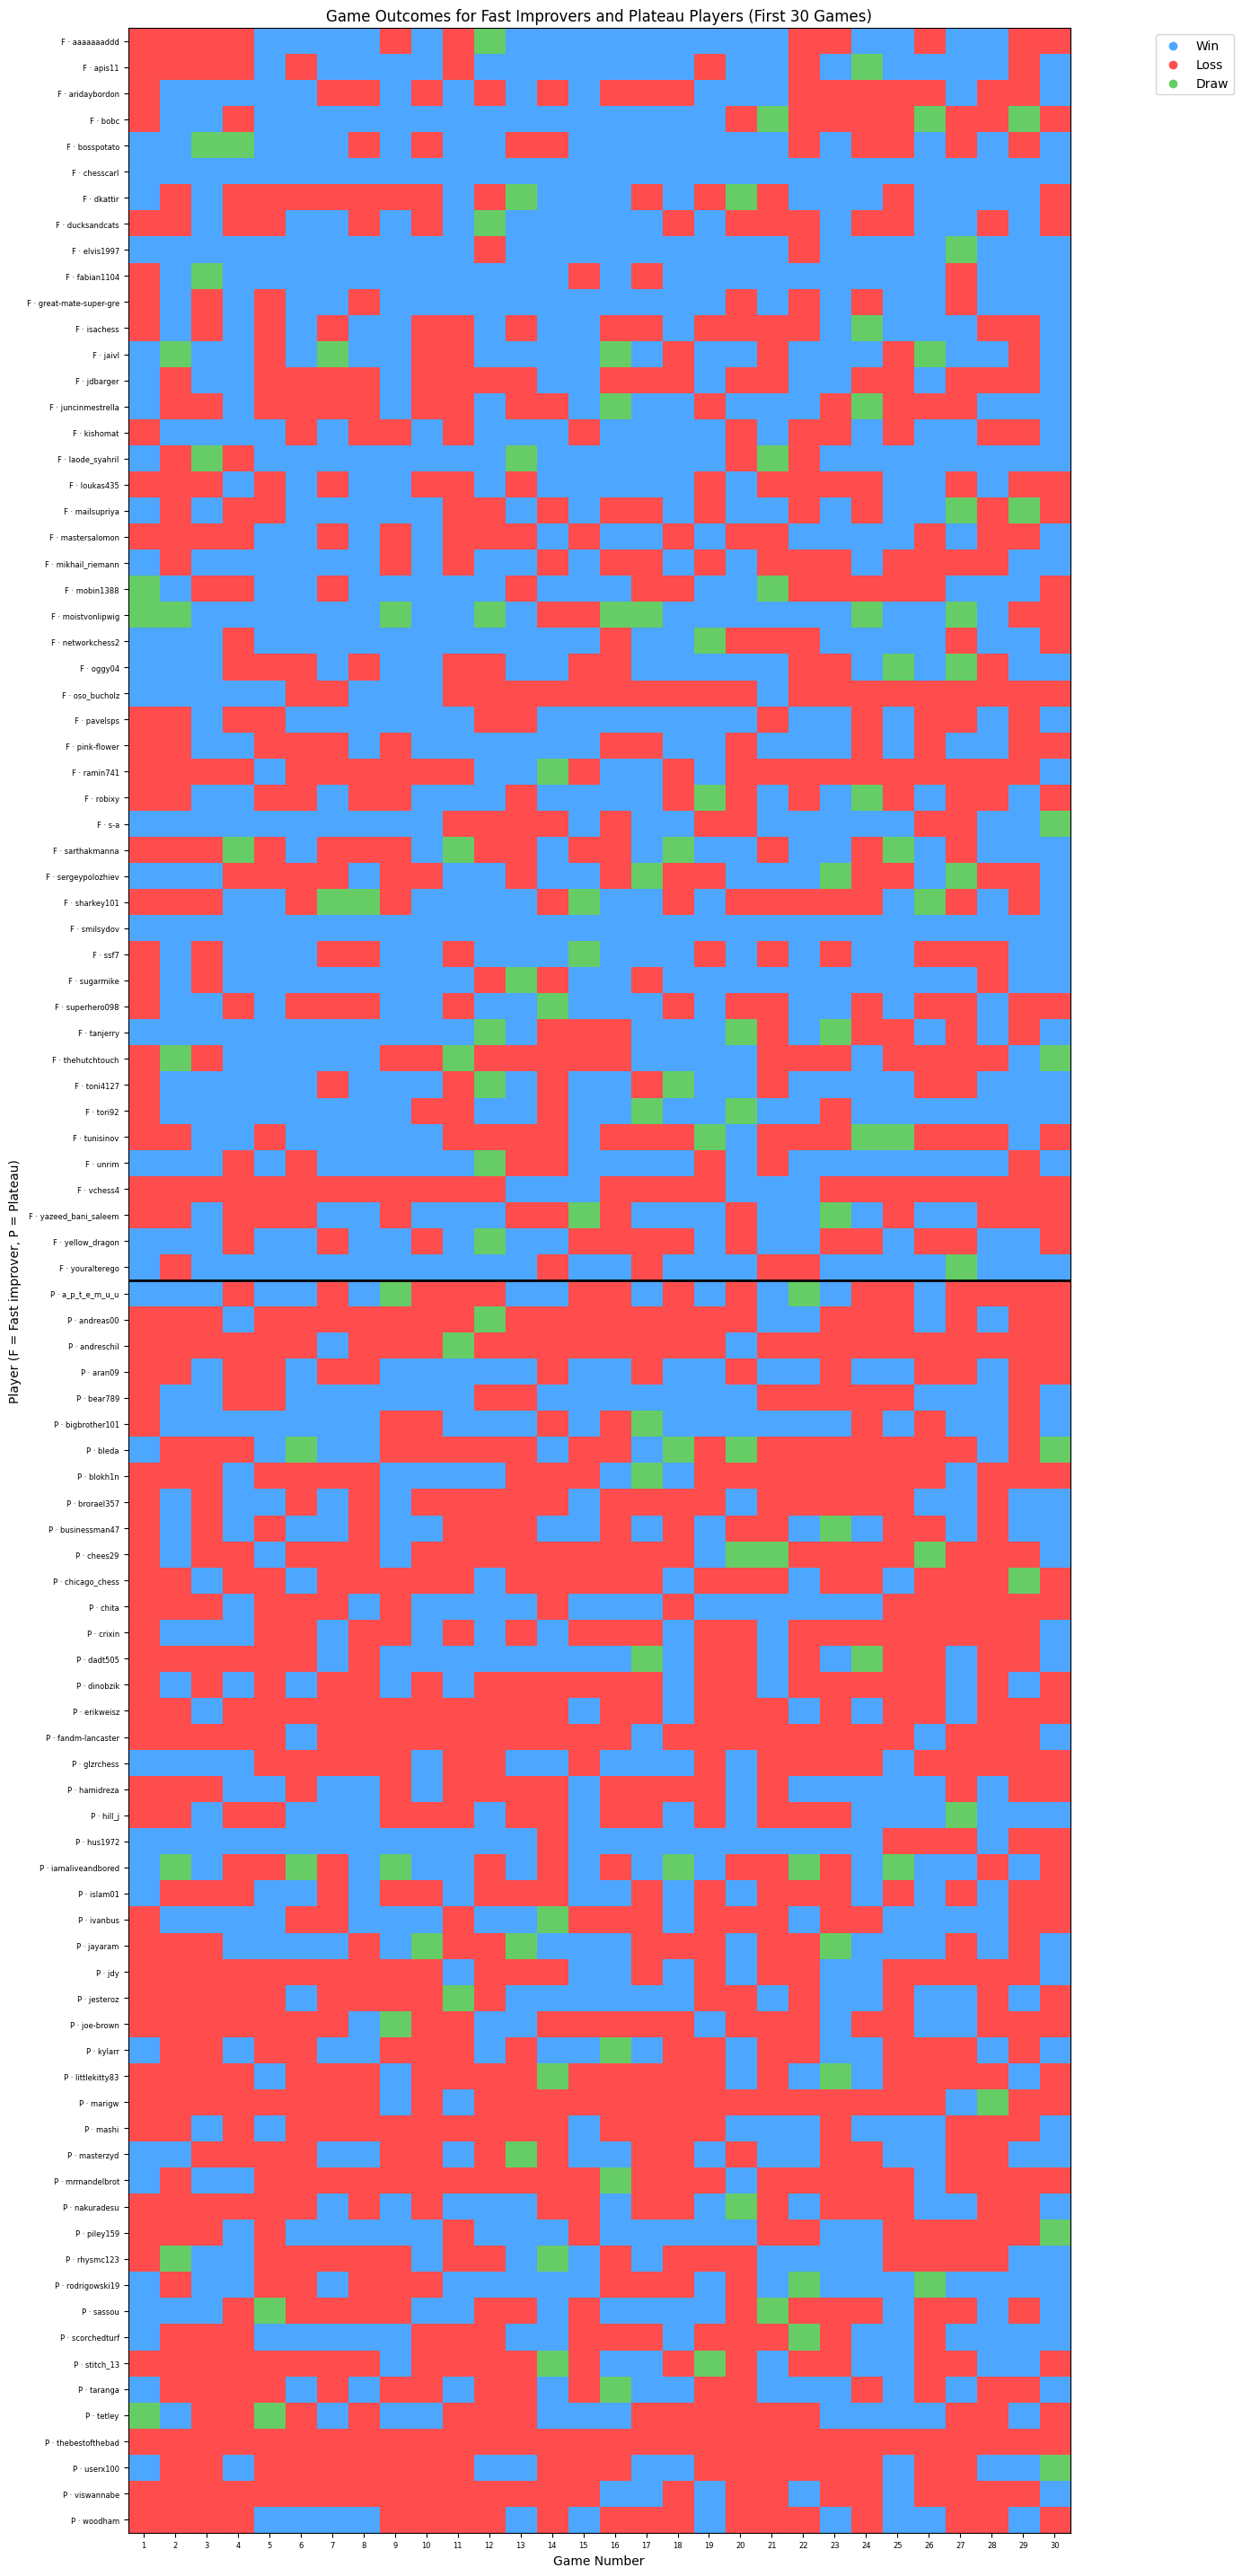

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# 1. Combine players & matrices
combined_players = (
    [f"F · {p}" for p in fast_players_list] +
    [f"P · {p}" for p in plateau_players_list]
)

combined_matrix = np.vstack([fast_matrix, plateau_matrix])

n_fast = len(fast_players_list)
n_total, n_games = combined_matrix.shape

# 2. Colormap: win = blue, loss = red, draw = green
cmap = ListedColormap(["#4da6ff", "#ff4d4d", "#66cc66"])

plt.figure(figsize=(14, n_total * 0.3))
plt.imshow(combined_matrix, aspect="auto", cmap=cmap)

# Y labels: all players, prefixed with F/P for group
plt.yticks(range(n_total), combined_players, fontsize=6)
plt.xticks(range(n_games), range(1, n_games + 1), fontsize=6)
plt.xlabel("Game Number")
plt.ylabel("Player (F = Fast improver, P = Plateau)")

plt.title("Game Outcomes for Fast Improvers and Plateau Players (First 30 Games)")

# Horizontal line separating groups
plt.axhline(y=n_fast - 0.5, color="black", linewidth=2)

# Simple legend using empty scatter points
plt.scatter([], [], color="#4da6ff", label="Win")
plt.scatter([], [], color="#ff4d4d", label="Loss")
plt.scatter([], [], color="#66cc66", label="Draw")
plt.legend(loc="upper right", bbox_to_anchor=(1.18, 1.0))

plt.tight_layout()
plt.show()


In [63]:
import json
from pathlib import Path

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)   # makes data/ if it doesn't exist


In [64]:
import numpy as np

# Combine fast + plateau matrices & labels
combined_players = (
    ["F: " + p for p in fast_players_list] +
    ["P: " + p for p in plateau_players_list]
)
combined_matrix = np.vstack([fast_matrix, plateau_matrix])  # shape (96, 30)

act1_heatmap_json = {
    "players": combined_players,                              # 96 player labels
    "games": list(range(1, combined_matrix.shape[1] + 1)),    # [1..30]
    "values": combined_matrix.tolist()                        # 0=win, 1=loss, 2=draw
}

with open(DATA_DIR / "act1_outcome_heatmap.json", "w") as f:
    json.dump(act1_heatmap_json, f, indent=2)


### Shared setup for Visuals 2 and 3

Here we compute per-player summaries for both groups:

- `wins` – total wins in the first 30 games  
- `wins_vs_higher` – wins where the opponent started with a higher rating  
- plus losses and draws (for context)


In [40]:
# Flag games where opponent starts higher rated
fast_df["higher_opp"] = fast_df["opponent_rating"] > fast_df["player_rating"]
plateau_df["higher_opp"] = plateau_df["opponent_rating"] > plateau_df["player_rating"]

def summarize_group(df):
    summary = df.groupby("player_id").agg(
        wins=("result", lambda x: (x == "win").sum()),
        wins_vs_higher=("result", 
                        lambda x: ((x == "win") & df.loc[x.index, "higher_opp"]).sum()),
        losses=("result", lambda x: (x == "loss").sum()),
        draws=("result", lambda x: (x == "draw").sum()),
    )
    return summary

fast_summary = summarize_group(fast_df)
fast_summary["group"] = "Fast"

plateau_summary = summarize_group(plateau_df)
plateau_summary["group"] = "Plateau"

combined_summary = pd.concat([fast_summary, plateau_summary])
combined_summary["player_label"] = (
    combined_summary["group"].str[0] + " · " + combined_summary.index
)

combined_summary.head()


,wins,wins_vs_higher,losses,draws,group,player_label
player_id,,,,,,
aaaaaaaddd,18,0,11,1,Fast,F · aaaaaaaddd
apis11,20,4,9,1,Fast,F · apis11
aridaybordon,14,4,16,0,Fast,F · aridaybordon
bobc,17,4,10,3,Fast,F · bobc
bosspotato,19,4,9,2,Fast,F · bosspotato


### Visual 2 — Top 10 Fast Improvers and Top 10 Plateau Players by Total Wins

This chart compares the early win performance of both groups directly.

- We take the **top 10 fast improvers** by total wins in their first 30 games.
- We take the **top 10 plateau players** in the same metric.
- Displaying them together highlights the contrast in early consistency and momentum.

Each bar shows how many games the player won out of the first 30.



In [44]:
# Select top 10 fast & plateau BY WINS (this defines our 20 players)
top_fast_wins = fast_summary.sort_values("wins", ascending=False).head(10)
top_plateau_wins = plateau_summary.sort_values("wins", ascending=False).head(10)

selected_fast_ids = top_fast_wins.index.tolist()
selected_plateau_ids = top_plateau_wins.index.tolist()

# Subset summaries for those players only
subset_fast = fast_summary.loc[selected_fast_ids].copy()
subset_fast["group"] = "Fast"

subset_plateau = plateau_summary.loc[selected_plateau_ids].copy()
subset_plateau["group"] = "Plateau"

selected_summary = pd.concat([subset_fast, subset_plateau])

# Label for plotting
selected_summary["player_label"] = (
    selected_summary["group"].str[0] + " · " + selected_summary.index
)

selected_summary.head()

,wins,wins_vs_higher,losses,draws,group,player_label
player_id,,,,,,
smilsydov,30,1,0,0,Fast,F · smilsydov
chesscarl,30,3,0,0,Fast,F · chesscarl
elvis1997,27,3,2,1,Fast,F · elvis1997
fabian1104,25,6,4,1,Fast,F · fabian1104
youralterego,24,0,5,1,Fast,F · youralterego


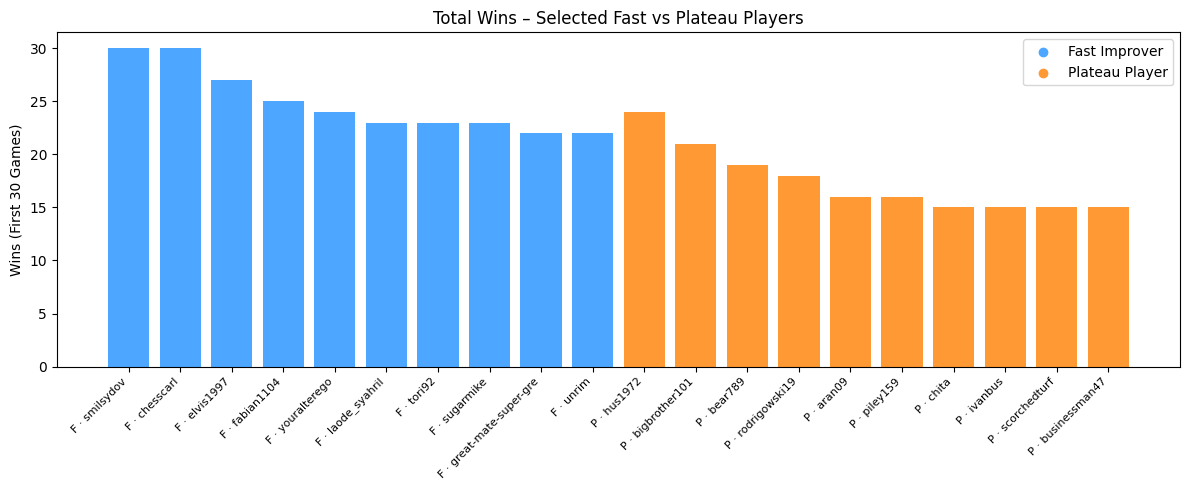

In [45]:
# Keep a fixed order: fast players first, then plateau players
order = list(subset_fast.index) + list(subset_plateau.index)
viz2 = selected_summary.loc[order]

colors = viz2["group"].map({"Fast": "#4da6ff", "Plateau": "#ff9933"})

plt.figure(figsize=(12, 5))
plt.bar(viz2["player_label"], viz2["wins"], color=colors)

plt.xticks(rotation=45, ha="right", fontsize=8)
plt.ylabel("Wins (First 30 Games)")
plt.title("Total Wins – Selected Fast vs Plateau Players")

# Legend
plt.scatter([], [], color="#4da6ff", label="Fast Improver")
plt.scatter([], [], color="#ff9933", label="Plateau Player")
plt.legend()

plt.tight_layout()
plt.show()



In [65]:
# choose 10 fast + 10 plateau players
fast_sample = fast_players_list[:10]
plateau_sample = plateau_players_list[:10]

def player_win_count(df, players):
    win_counts = []
    labels = []
    for p in players:
        subset = df[(df["player_id"] == p) & (df["game_number"] <= 30)]
        wins = (subset["result"] == "win").sum()
        win_counts.append(int(wins))
        labels.append(p)
    return labels, win_counts

fast_labels, fast_wins = player_win_count(fast_df, fast_sample)
plateau_labels, plateau_wins = player_win_count(plateau_df, plateau_sample)

selected_players = ["F: " + p for p in fast_labels] + ["P: " + p for p in plateau_labels]
selected_wins = fast_wins + plateau_wins
selected_group = (["Fast"] * len(fast_labels)) + (["Plateau"] * len(plateau_labels))

act1_total_wins_json = {
    "players": selected_players,   # 20 labels
    "wins": selected_wins,         # 20 numbers
    "group": selected_group        # "Fast" / "Plateau"
}

with open(DATA_DIR / "act1_total_wins.json", "w") as f:
    json.dump(act1_total_wins_json, f, indent=2)


### Visual 3 — Top 10 Fast Improvers and Top 10 Plateau Players by Wins vs Higher-Rated Opponents

This visualization focuses on *upset wins* — victories against stronger opponents.

- We take the **top 10 fast improvers** by wins vs higher-rated players.
- We take the **top 10 plateau players** by the same metric.

This highlights early adaptability, resilience, and strategic growth.

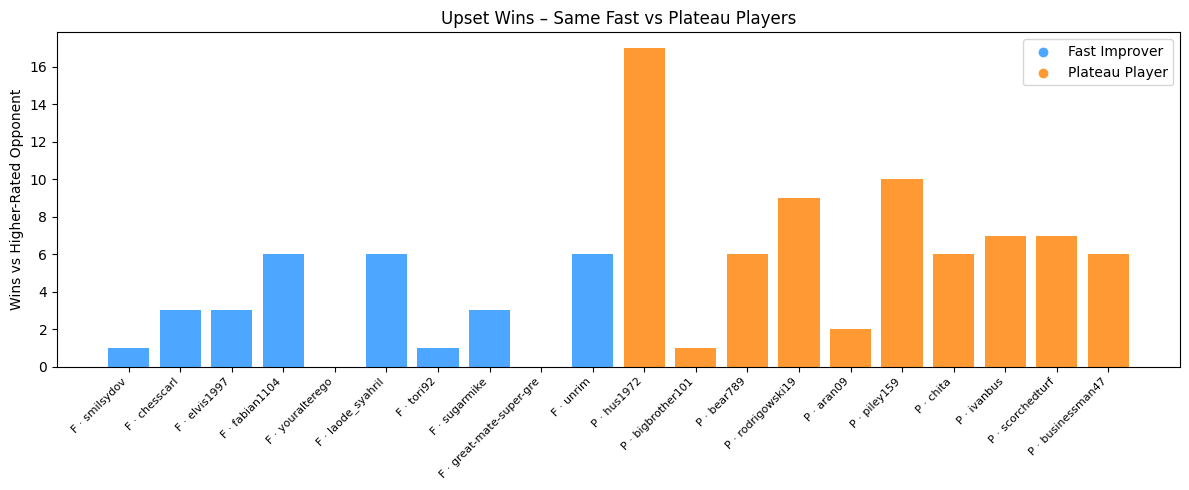

In [46]:
viz3 = viz2.copy()  # same order & labels
colors = viz3["group"].map({"Fast": "#4da6ff", "Plateau": "#ff9933"})

plt.figure(figsize=(12, 5))
plt.bar(viz3["player_label"], viz3["wins_vs_higher"], color=colors)

plt.xticks(rotation=45, ha="right", fontsize=8)
plt.ylabel("Wins vs Higher-Rated Opponent")
plt.title("Upset Wins – Same Fast vs Plateau Players")

plt.scatter([], [], color="#4da6ff", label="Fast Improver")
plt.scatter([], [], color="#ff9933", label="Plateau Player")
plt.legend()

plt.tight_layout()
plt.show()



In [66]:
def upset_wins_for_players(df, players):
    upset_counts = []
    for p in players:
        subset = df[(df["player_id"] == p) & (df["game_number"] <= 30)]
        upsets = ((subset["result"] == "win") & (subset["higher_opp"] == True)).sum()
        upset_counts.append(int(upsets))
    return upset_counts

fast_upsets = upset_wins_for_players(fast_df, fast_sample)
plateau_upsets = upset_wins_for_players(plateau_df, plateau_sample)

selected_upsets = fast_upsets + plateau_upsets

act1_upset_wins_json = {
    "players": selected_players,   # same order as total_wins
    "upset_wins": selected_upsets,
    "group": selected_group
}

with open(DATA_DIR / "act1_upset_wins.json", "w") as f:
    json.dump(act1_upset_wins_json, f, indent=2)


## Act 2 – Where are games actually decided?

Because this dataset doesn’t include engine error metrics (no individual
“inaccuracies” or “blunders” columns), I use **game length** as a proxy
for which phase decided the result:

- **Opening-decided games:** up to 20 moves  
- **Middlegame-decided games:** 21–40 moves  
- **Endgame-decided games:** 41+ moves  

Short games usually end in the opening or early tactics, mid-length
games are dominated by middlegame decisions, and long games tend to
reach simplified endgames.

For each group (fast vs plateau), I compute the win rate in each length
bucket. This shows where each group is most successful: quick tactical
strikes, middlegame fights, or grindy long games.


Win rates by length bucket:
                        Fast   Plateau
length_bucket                         
Opening (≤20)       0.605505  0.373383
Middlegame (21–40)  0.602528  0.354735
Endgame (41+)       0.493766  0.373188


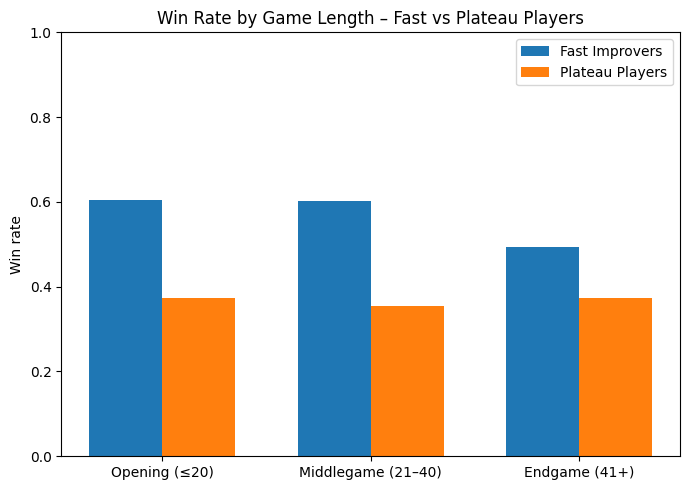

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Helper: bucket games by length (in full moves) ----
def length_bucket(full_moves):
    if full_moves <= 20:
        return "Opening (≤20)"
    elif full_moves <= 40:
        return "Middlegame (21–40)"
    else:
        return "Endgame (41+)"


def add_length_and_bucket(df):
    temp = df.copy()
    # In this dataset, `turns` is number of half-moves.
    # Convert to full moves.
    if "turns" in temp.columns:
        temp["full_moves"] = (temp["turns"] / 2).round().astype(int)
    else:
        # fallback: count from moves string
        temp["full_moves"] = temp["moves"].astype(str).str.split().str.len() // 2

    temp["length_bucket"] = temp["full_moves"].apply(length_bucket)
    return temp


# Add length + bucket to fast and plateau data
fast_len = add_length_and_bucket(fast_df)
plateau_len = add_length_and_bucket(plateau_df)

# ---- Compute win rate in each bucket ----
def win_rate_by_bucket(df, label):
    tmp = df.copy()
    tmp["is_win"] = (tmp["result"] == "win").astype(int)
    w = (
        tmp.groupby("length_bucket")["is_win"]
           .mean()
           .reindex(["Opening (≤20)", "Middlegame (21–40)", "Endgame (41+)"])
    )
    w.name = label
    return w

fast_bucket_wr = win_rate_by_bucket(fast_len, "Fast")
plateau_bucket_wr = win_rate_by_bucket(plateau_len, "Plateau")

print("Win rates by length bucket:")
print(pd.concat([fast_bucket_wr, plateau_bucket_wr], axis=1))

# ---- Plot ----
x = np.arange(3)
width = 0.35

plt.figure(figsize=(7,5))
plt.bar(x - width/2, fast_bucket_wr.values, width, label="Fast Improvers")
plt.bar(x + width/2, plateau_bucket_wr.values, width, label="Plateau Players")

plt.xticks(x, fast_bucket_wr.index, rotation=0)
plt.ylabel("Win rate")
plt.ylim(0, 1)
plt.title("Win Rate by Game Length – Fast vs Plateau Players")
plt.legend()
plt.tight_layout()
plt.show()




In [67]:
import json
from pathlib import Path
import numpy as np
import pandas as pd

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

# -------------------------------------------------------------------
# Helper: combined dataframe with group labels
# -------------------------------------------------------------------
fast_all = fast_df.copy()
fast_all["group"] = "Fast Improvers"

plateau_all = plateau_df.copy()
plateau_all["group"] = "Plateau Players"

all_games = pd.concat([fast_all, plateau_all], ignore_index=True)


Fast Improvers – phase counts:
phase
Middlegame (21–40)    728
Endgame (41+)         414
Opening (≤20)         298
Name: count, dtype: int64

Plateau Players – phase counts:
phase
Middlegame (21–40)    633
Opening (≤20)         521
Endgame (41+)         286
Name: count, dtype: int64

Win rate by group and phase (%):
phase            Endgame (41+)  Middlegame (21–40)  Opening (≤20)
group                                                            
Fast Improvers            49.5                60.3           60.7
Plateau Players           36.4                35.7           37.6


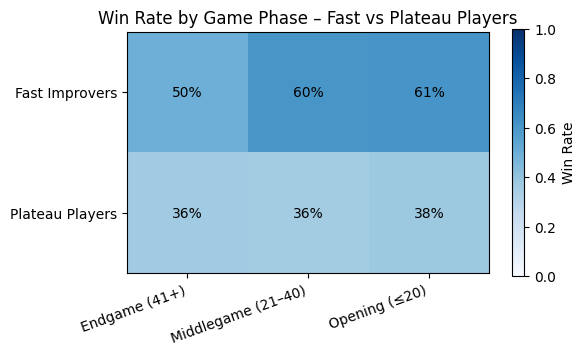

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# 1. From move string → full move count → phase label
# =====================================================

def estimate_full_moves(moves_str):
    """
    moves_str: string like 'd4 e6 Bf4 f5 e3 d5 ...'
    Each token is a half-move, so full_moves = len(tokens) / 2.
    """
    if pd.isna(moves_str):
        return np.nan
    tokens = str(moves_str).split()
    half_moves = len(tokens)
    full_moves = half_moves / 2.0
    return full_moves

def classify_phase(full_moves):
    """
    Convert # full moves into chess phase:
    Opening (≤20), Middlegame (21–40), Endgame (41+).
    """
    if pd.isna(full_moves):
        return np.nan
    if full_moves <= 20:
        return "Opening (≤20)"
    elif full_moves <= 40:
        return "Middlegame (21–40)"
    else:
        return "Endgame (41+)"

# Add full move counts
fast_df["full_moves"] = fast_df["moves"].apply(estimate_full_moves)
plateau_df["full_moves"] = plateau_df["moves"].apply(estimate_full_moves)

# Add phase labels
fast_df["phase"] = fast_df["full_moves"].apply(classify_phase)
plateau_df["phase"] = plateau_df["full_moves"].apply(classify_phase)

# Optional: sanity-check how many games fall in each phase
print("Fast Improvers – phase counts:")
print(fast_df["phase"].value_counts(dropna=False))
print("\nPlateau Players – phase counts:")
print(plateau_df["phase"].value_counts(dropna=False))

# =====================================================
# 2. Combine into one table and compute win rates
# =====================================================

# Tag each group
fast_tmp = fast_df.copy()
fast_tmp["group"] = "Fast Improvers"

plat_tmp = plateau_df.copy()
plat_tmp["group"] = "Plateau Players"

phase_table = pd.concat([fast_tmp, plat_tmp], ignore_index=True)

# Boolean win indicator
phase_table["is_win"] = (phase_table["result"] == "win")

# Win rate by (group, phase)
phase_wr = (
    phase_table
      .groupby(["group", "phase"])["is_win"]
      .mean()
      .unstack("phase")
)

print("\nWin rate by group and phase (%):")
print((phase_wr * 100).round(1))

# =====================================================
# 3. Plot heatmap – Win Rate by Game Phase
# =====================================================

data   = phase_wr.values
groups = phase_wr.index.tolist()
phases = phase_wr.columns.tolist()

fig, ax = plt.subplots(figsize=(6, 3.5))

im = ax.imshow(data, cmap="Blues", vmin=0, vmax=1)

# Axis labels
ax.set_yticks(np.arange(len(groups)))
ax.set_yticklabels(groups)

ax.set_xticks(np.arange(len(phases)))
ax.set_xticklabels(phases, rotation=20, ha="right")

# Annotate cells with percentages
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(j, i, f"{data[i, j]*100:.0f}%",
                ha="center", va="center", color="black")

ax.set_title("Win Rate by Game Phase – Fast vs Plateau Players")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Win Rate")

plt.tight_layout()
plt.show()


In [73]:
# --------------------- Act 2 – Visual 1 JSON -----------------------

def classify_phase_from_moves(moves_str):
    if isinstance(moves_str, str):
        num_moves = len(moves_str.split())
    else:
        num_moves = 0

    if num_moves <= 20:
        return "Opening (≤20)"
    elif num_moves <= 40:
        return "Middlegame (21–40)"
    else:
        return "Endgame (41+)"

all_games["phase"] = all_games["moves"].apply(classify_phase_from_moves)

# compute win rates per group, per phase
phase_summary = (
    all_games
    .groupby(["group", "phase"])["result"]
    .value_counts()
    .unstack(fill_value=0)
)

# ensure all groups/phases exist
groups = ["Fast Improvers", "Plateau Players"]
phases = ["Opening (≤20)", "Middlegame (21–40)", "Endgame (41+)"]

win_rate_matrix = []
for g in groups:
    row = []
    for ph in phases:
        if (g, ph) in phase_summary.index:
            counts = phase_summary.loc[(g, ph)]
            total = counts.sum()
            win_rate = float(counts.get("win", 0) / total) if total > 0 else 0.0
        else:
            win_rate = 0.0
        row.append(win_rate)
    win_rate_matrix.append(row)

act2_phase_json = {
    "groups": groups,
    "phases": phases,
    "win_rates": win_rate_matrix
}

with open(DATA_DIR / "act2_winrate_phase.json", "w") as f:
    json.dump(act2_phase_json, f, indent=2)

## Act 2 — Visual 2: Does Opening Depth Predict Success?

Another way to measure adaptability is by looking at **how deep each opening goes** before players leave known theory.

- A shallow opening (1–3 moves) usually means someone deviates early, often leading to tactical chaos.
- A deeper opening (6+ moves) suggests comfort in structured, theoretical positions.

If fast improvers are genuinely learning, they should perform **better** in deeper openings, whereas plateau players may not benefit from complexity.

The chart compares win rate as a function of opening depth for both groups.


                          Fast   Plateau
opening_depth_bucket                    
Very Shallow (≤3)     0.584615  0.337386
Shallow (4–6)         0.563964  0.389474
Moderate (7–10)       0.563291  0.373057
Deep (11+)            0.596491  0.526316


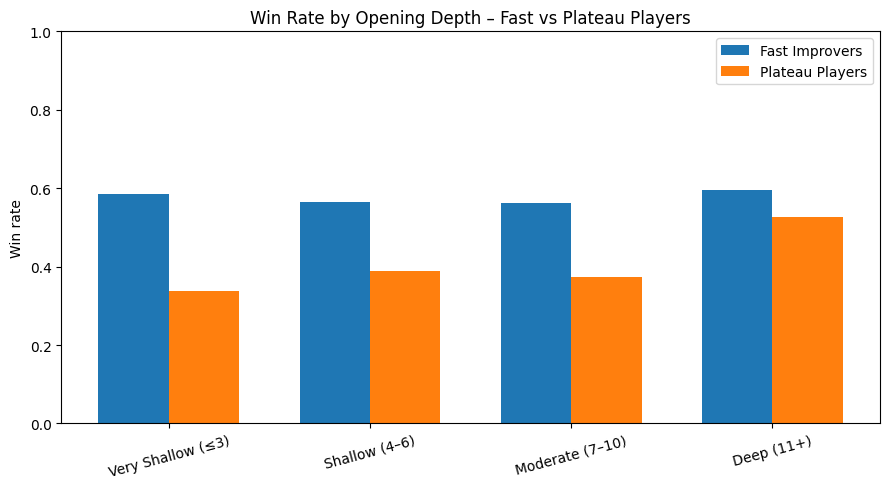

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def opening_depth_bucket(n):
    if n <= 3:
        return "Very Shallow (≤3)"
    elif n <= 6:
        return "Shallow (4–6)"
    elif n <= 10:
        return "Moderate (7–10)"
    else:
        return "Deep (11+)"

def add_opening_bucket(df):
    temp = df.copy()
    temp["opening_depth_bucket"] = df["opening_moves"].apply(opening_depth_bucket)
    return temp


# Add depth buckets
fast_open = add_opening_bucket(fast_df)
plateau_open = add_opening_bucket(plateau_df)

# Compute win rates
def win_rate_by_opening_depth(df, label):
    tmp = df.copy()
    tmp["is_win"] = (tmp["result"] == "win").astype(int)
    wr = (
        tmp.groupby("opening_depth_bucket")["is_win"]
           .mean()
           .reindex(["Very Shallow (≤3)", "Shallow (4–6)", "Moderate (7–10)", "Deep (11+)"])
    )
    wr.name = label
    return wr

fast_open_wr = win_rate_by_opening_depth(fast_open, "Fast")
plateau_open_wr = win_rate_by_opening_depth(plateau_open, "Plateau")

# Display numbers
print(pd.concat([fast_open_wr, plateau_open_wr], axis=1))

# Plot
x = np.arange(4)
width = 0.35

plt.figure(figsize=(9,5))
plt.bar(x - width/2, fast_open_wr.values, width, label="Fast Improvers")
plt.bar(x + width/2, plateau_open_wr.values, width, label="Plateau Players")

plt.xticks(x, fast_open_wr.index, rotation=15)
plt.ylabel("Win rate")
plt.ylim(0, 1)
plt.title("Win Rate by Opening Depth – Fast vs Plateau Players")
plt.legend()
plt.tight_layout()
plt.show()


In [72]:
# --------------------- Act 2 – Visual 2 JSON -----------------------

# make sure opening_moves is numeric
all_games["opening_moves"] = pd.to_numeric(
    all_games["opening_moves"], errors="coerce"
)

def opening_bucket(n):
    if pd.isna(n):
        return "Unknown"
    n = int(n)
    if n <= 3:
        return "Very Shallow (≤3)"
    elif n <= 6:
        return "Shallow (4–6)"
    elif n <= 10:
        return "Moderate (7–10)"
    else:
        return "Deep (11+)"

all_games["opening_bucket"] = all_games["opening_moves"].apply(opening_bucket)

depth_summary = (
    all_games
    .groupby(["group", "opening_bucket"])["result"]
    .value_counts()
    .unstack(fill_value=0)
)

depth_buckets = [
    "Very Shallow (≤3)",
    "Shallow (4–6)",
    "Moderate (7–10)",
    "Deep (11+)"
]

depth_win_matrix = []
for g in groups:
    row = []
    for b in depth_buckets:
        if (g, b) in depth_summary.index:
            counts = depth_summary.loc[(g, b)]
            total = counts.sum()
            win_rate = float(counts.get("win", 0) / total) if total > 0 else 0.0
        else:
            win_rate = 0.0
        row.append(win_rate)
    depth_win_matrix.append(row)

act2_opening_depth_json = {
    "groups": groups,
    "buckets": depth_buckets,
    "win_rates": depth_win_matrix
}

with open(DATA_DIR / "act2_opening_depth.json", "w") as f:
    json.dump(act2_opening_depth_json, f, indent=2)


### Act 3 — Off-Book Adaptability

Openings give players a safety net: familiar structures, memorized lines, and predictable replies.  
But once the game leaves theory (“off-book”), the position becomes unfamiliar and decision-making becomes much harder.  
This moment separates memorization from actual understanding.

We group games into three categories based on when they leave theory:

- **Early (≤4 moves):** chaotic, principle-driven positions  
- **Mid (5–7 moves):** partially structured  
- **Late (8+ moves):** deep theory where weaker players feel safest  

Fast improvers maintain a stable win rate across all three categories.  
Plateau players collapse when the opening ends early and perform best only when heavily supported by book lines.

This shows that:

> **Fast improvers adapt well in unfamiliar positions. Plateau players rely on structure to survive.**


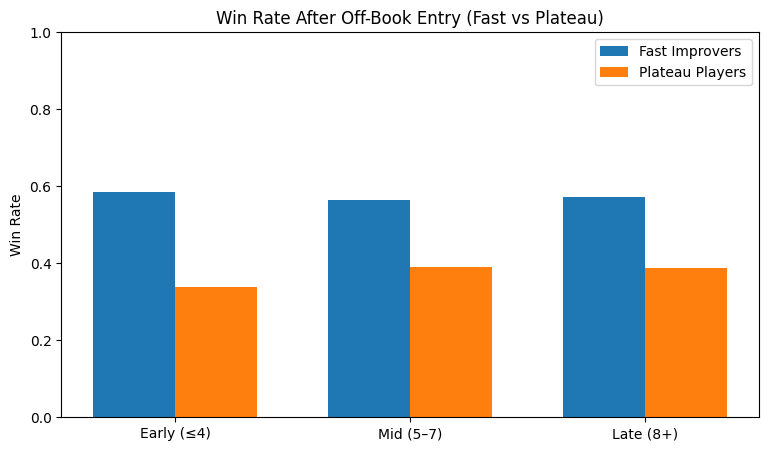

In [51]:
# -------------------------------
# ACT 3 — Off-Book Adaptability
# -------------------------------

# 1. Compute off-book move (one move after opening theory ends)
fast_df["offbook_move"] = fast_df["opening_moves"].fillna(0).astype(int) + 1
plateau_df["offbook_move"] = plateau_df["opening_moves"].fillna(0).astype(int) + 1

# 2. Bucket off-book timing
def offbook_bucket(n):
    if n <= 4:
        return "Early (≤4)"
    elif n <= 7:
        return "Mid (5–7)"
    else:
        return "Late (8+)"

fast_df["offbook_bucket"] = fast_df["offbook_move"].apply(offbook_bucket)
plateau_df["offbook_bucket"] = plateau_df["offbook_move"].apply(offbook_bucket)

# 3. Compute win rate by bucket
fast_offbook_wr = fast_df.groupby("offbook_bucket")["result"].apply(lambda x: (x=="win").mean())
plateau_offbook_wr = plateau_df.groupby("offbook_bucket")["result"].apply(lambda x: (x=="win").mean())

# 4. Plot Off-Book Win Rates
import matplotlib.pyplot as plt
import numpy as np

buckets = ["Early (≤4)", "Mid (5–7)", "Late (8+)"]
x = np.arange(len(buckets))
width = 0.35

plt.figure(figsize=(9,5))
plt.bar(x - width/2, fast_offbook_wr[buckets], width, label="Fast Improvers")
plt.bar(x + width/2, plateau_offbook_wr[buckets], width, label="Plateau Players")

plt.xticks(x, buckets)
plt.ylabel("Win Rate")
plt.title("Win Rate After Off-Book Entry (Fast vs Plateau)")
plt.ylim(0,1)
plt.legend()
plt.show()


In [74]:
# --------------------- Act 3 – Visual 1 JSON -----------------------

offbook_games = all_games.dropna(subset=["offbook_bucket"]).copy()

offbook_summary = (
    offbook_games
    .groupby(["group", "offbook_bucket"])["result"]
    .value_counts()
    .unstack(fill_value=0)
)

offbook_buckets = ["Early (≤4)", "Mid (5–7)", "Late (8+)"]

offbook_win_matrix = []
for g in groups:
    row = []
    for b in offbook_buckets:
        if (g, b) in offbook_summary.index:
            counts = offbook_summary.loc[(g, b)]
            total = counts.sum()
            win_rate = float(counts.get("win", 0) / total) if total > 0 else 0.0
        else:
            win_rate = 0.0
        row.append(win_rate)
    offbook_win_matrix.append(row)

act3_offbook_win_json = {
    "groups": groups,
    "buckets": offbook_buckets,
    "win_rates": offbook_win_matrix
}

with open(DATA_DIR / "act3_offbook_winrate.json", "w") as f:
    json.dump(act3_offbook_win_json, f, indent=2)


### Post-Book Error Stability

Once the game leaves book, decision-making must rely on understanding rather than memorized lines.  
This makes inaccuracies, mistakes, and blunders extremely revealing.

Fast improvers show stable error levels even when off-book positions are chaotic.  
Plateau players show sharp spikes in errors when the opening ends early, indicating difficulty in adapting to unfamiliar positions.

This reinforces a core theme:

> **Improvement is not about perfection; it is about controlling damage when the game becomes unstable.**


Fast improvers – upset win rates:
offbook_bucket
Early (≤4)    0.348837
Late (8+)     0.397059
Mid (5–7)     0.375000
Name: result, dtype: float64

Plateau players – upset win rates:
offbook_bucket
Early (≤4)    0.227373
Late (8+)     0.308219
Mid (5–7)     0.290909
Name: result, dtype: float64


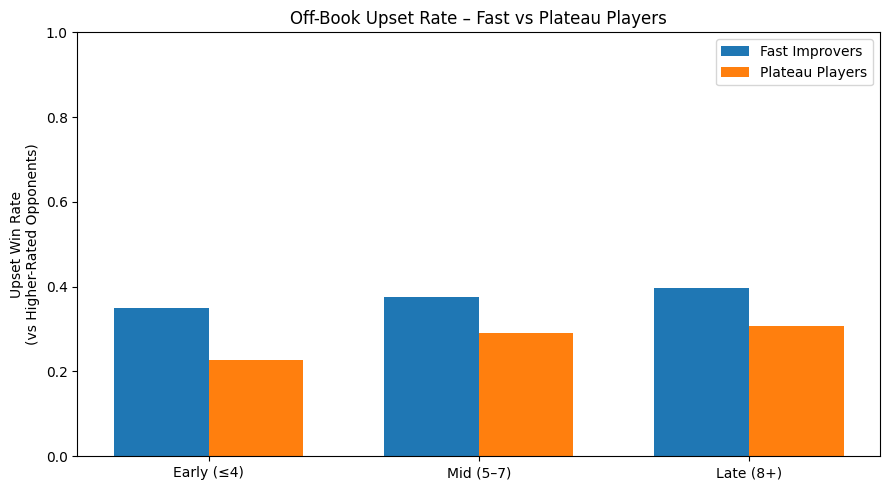

In [54]:
# ----------------------------------------
# ACT 3 — Off-Book Upset Ability
# ----------------------------------------

# We assume you already have:
#   fast_df, plateau_df
#   offbook_bucket and result columns
#   'higher_opp' == 1 when opponent rating > player rating

# Filter only games vs higher-rated opponents
fast_upset_df = fast_df[fast_df["higher_opp"] == 1].copy()
plateau_upset_df = plateau_df[plateau_df["higher_opp"] == 1].copy()

# Compute upset win rate by off-book bucket
def upset_wr_by_bucket(df):
    if df.empty:
        return pd.Series(dtype=float)
    return df.groupby("offbook_bucket")["result"].apply(lambda x: (x=="win").mean())

fast_upset_wr = upset_wr_by_bucket(fast_upset_df)
plateau_upset_wr = upset_wr_by_bucket(plateau_upset_df)

print("Fast improvers – upset win rates:")
print(fast_upset_wr)
print("\nPlateau players – upset win rates:")
print(plateau_upset_wr)

# Make sure we use the same bucket order as before
buckets = ["Early (≤4)", "Mid (5–7)", "Late (8+)"]

# For any bucket missing in a group, fill with 0 (or np.nan if you prefer)
fast_vals    = [fast_upset_wr.get(b, 0) for b in buckets]
plateau_vals = [plateau_upset_wr.get(b, 0) for b in buckets]

# Plot upset win rates
plt.figure(figsize=(9,5))
x = np.arange(len(buckets))
width = 0.35

plt.bar(x - width/2, fast_vals, width, label="Fast Improvers")
plt.bar(x + width/2, plateau_vals, width, label="Plateau Players")

plt.xticks(x, buckets)
plt.ylabel("Upset Win Rate\n(vs Higher-Rated Opponents)")
plt.title("Off-Book Upset Rate – Fast vs Plateau Players")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


### 3C. Bounce-Back Ability (Winning After a Loss)

Adaptability is not only about openings—it’s also mental.

A strong player doesn't collapse after a bad game.  
To capture this, I compute the probability of winning the game *immediately after* a loss.

Fast improvers show a dramatically higher bounce-back rate than plateau players,
which suggests:

- better emotional regulation  
- stronger ability to reset  
- higher long-term learning capacity  

This is a key behavioural marker of improvement.


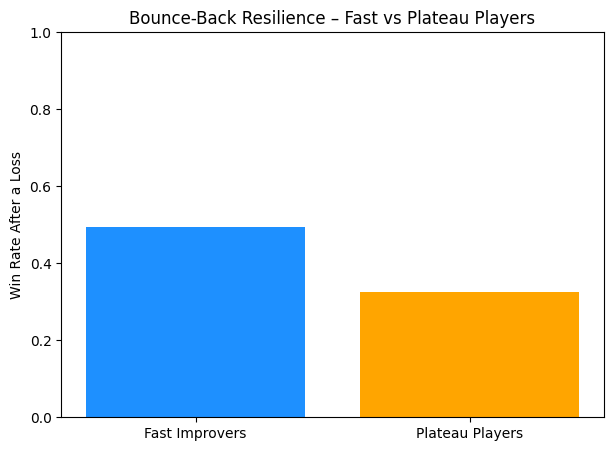

Fast improver bounce-back rate: 0.49333333333333335
Plateau bounce-back rate: 0.32419547079856975


In [55]:
def bounce_rate(df):
    df = df.sort_values(["player_id", "game_number"])
    df["prev_result"] = df.groupby("player_id")["result"].shift(1)
    after_loss = df[df["prev_result"] == "loss"]
    return (after_loss["result"] == "win").mean()

fast_bounce = bounce_rate(fast_df)
plateau_bounce = bounce_rate(plateau_df)

plt.figure(figsize=(7,5))
plt.bar(["Fast Improvers","Plateau Players"], [fast_bounce, plateau_bounce],
        color=["dodgerblue","orange"])
plt.ylabel("Win Rate After a Loss")
plt.title("Bounce-Back Resilience – Fast vs Plateau Players")
plt.ylim(0,1)
plt.show()

print("Fast improver bounce-back rate:", fast_bounce)
print("Plateau bounce-back rate:", plateau_bounce)


In [75]:
# --------------------- Act 3 – Visual 3 JSON -----------------------

def bounce_back_rate(df):
    tmp = df.sort_values(["player_id", "game_number"]).copy()
    tmp["prev_result"] = tmp.groupby("player_id")["result"].shift(1)
    after_loss = tmp[tmp["prev_result"] == "loss"]
    if len(after_loss) == 0:
        return 0.0
    wins_after = (after_loss["result"] == "win").sum()
    return float(wins_after / len(after_loss))

fast_bounce = bounce_back_rate(fast_df)
plateau_bounce = bounce_back_rate(plateau_df)

act3_bounce_json = {
    "groups": ["Fast Improvers", "Plateau Players"],
    "bounce_rate": [fast_bounce, plateau_bounce]
}

with open(DATA_DIR / "act3_bounce_back.json", "w") as f:
    json.dump(act3_bounce_json, f, indent=2)


Win rate by off-book bucket:
offbook_bucket   Early (≤4)  Late (8+)  Mid (5–7)
group                                            
Fast Improvers         58.5       57.2       56.4
Plateau Players        33.7       38.7       38.9


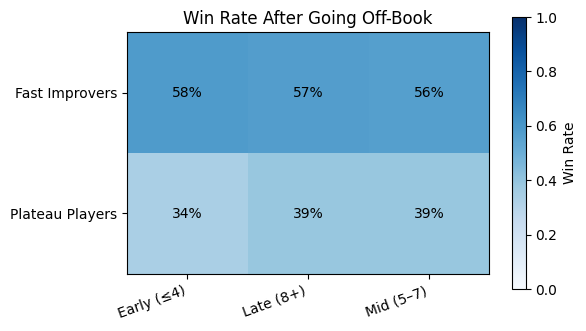


Upset win rate (vs higher-rated opponent) by off-book bucket:
offbook_bucket   Early (≤4)  Late (8+)  Mid (5–7)
group                                            
Fast Improvers         34.9       39.7       37.5
Plateau Players        22.7       30.8       29.1


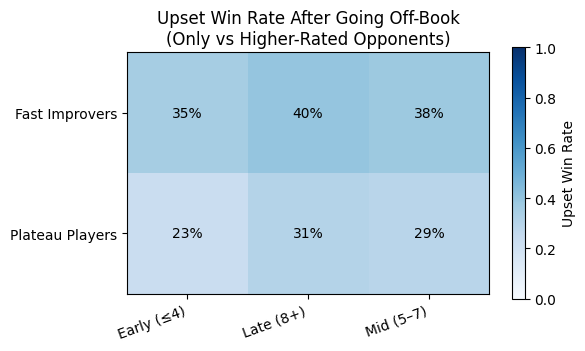


Transition matrix – Fast Improvers (P(next | prev)):
result        win  loss  draw
prev_result                  
win          64.1  30.9   5.0
loss         49.3  45.7   5.0
draw         50.7  42.3   7.0

Transition matrix – Plateau Players (P(next | prev)):
result        win  loss  draw
prev_result                  
win          43.4  51.7   5.0
loss         32.4  64.7   2.9
draw         43.8  54.2   2.1


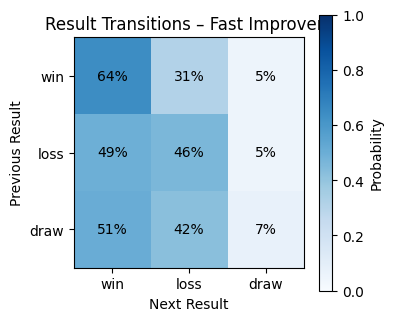

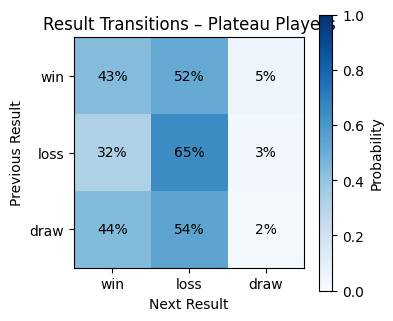

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# Combine into one table with a 'group' column
# =====================================================

fast_tmp = fast_df.copy()
fast_tmp["group"] = "Fast Improvers"

plat_tmp = plateau_df.copy()
plat_tmp["group"] = "Plateau Players"

games_all = pd.concat([fast_tmp, plat_tmp], ignore_index=True)

# Convenience boolean: win or not
games_all["is_win"] = (games_all["result"] == "win")

# -----------------------------------------------------
# VISUAL 1: Off-book timing vs overall win rate
# -----------------------------------------------------

wr_offbook = (
    games_all
      .groupby(["group", "offbook_bucket"])["is_win"]
      .mean()
      .unstack("offbook_bucket")
)

print("Win rate by off-book bucket:")
print((wr_offbook * 100).round(1))

fig, ax = plt.subplots(figsize=(6, 3.5))
data = wr_offbook.values
groups = wr_offbook.index.tolist()
buckets = wr_offbook.columns.tolist()

im = ax.imshow(data, cmap="Blues", vmin=0, vmax=1)

ax.set_yticks(np.arange(len(groups)))
ax.set_yticklabels(groups)
ax.set_xticks(np.arange(len(buckets)))
ax.set_xticklabels(buckets, rotation=20, ha="right")

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(j, i, f"{data[i, j]*100:.0f}%",
                ha="center", va="center", color="black")

ax.set_title("Win Rate After Going Off-Book")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Win Rate")
plt.tight_layout()
plt.show()

# -----------------------------------------------------
# VISUAL 2: Off-book upset rate (vs higher-rated opps)
# -----------------------------------------------------

upset = games_all[games_all["higher_opp"] == True].copy()
wr_upset = (
    upset
      .groupby(["group", "offbook_bucket"])["is_win"]
      .mean()
      .unstack("offbook_bucket")
)

print("\nUpset win rate (vs higher-rated opponent) by off-book bucket:")
print((wr_upset * 100).round(1))

fig, ax = plt.subplots(figsize=(6, 3.5))
data = wr_upset.values
groups = wr_upset.index.tolist()
buckets = wr_upset.columns.tolist()

im = ax.imshow(data, cmap="Blues", vmin=0, vmax=1)

ax.set_yticks(np.arange(len(groups)))
ax.set_yticklabels(groups)
ax.set_xticks(np.arange(len(buckets)))
ax.set_xticklabels(buckets, rotation=20, ha="right")

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(j, i, f"{data[i, j]*100:.0f}%",
                ha="center", va="center", color="black")

ax.set_title("Upset Win Rate After Going Off-Book\n(Only vs Higher-Rated Opponents)")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Upset Win Rate")
plt.tight_layout()
plt.show()

# -----------------------------------------------------
# VISUAL 3: Resilience – result transition matrix
# -----------------------------------------------------

def result_transition_matrix(df_group):
    """
    df_group: games for a single group (fast or plateau),
              must have player_id, game_number, result
    Returns a 3x3 matrix of P(next_result | prev_result)
    """
    df = df_group.sort_values(["player_id", "game_number"]).copy()
    df["prev_result"] = df.groupby("player_id")["result"].shift(1)
    trans = df.dropna(subset=["prev_result"]).copy()

    # Build probability matrix
    results_order = ["win", "loss", "draw"]
    ctab = (
        pd.crosstab(trans["prev_result"], trans["result"], normalize="index")
          .reindex(index=results_order, columns=results_order, fill_value=0.0)
    )
    return ctab

fast_trans = result_transition_matrix(games_all[games_all["group"] == "Fast Improvers"])
plateau_trans = result_transition_matrix(games_all[games_all["group"] == "Plateau Players"])

print("\nTransition matrix – Fast Improvers (P(next | prev)):")
print((fast_trans * 100).round(1))
print("\nTransition matrix – Plateau Players (P(next | prev)):")
print((plateau_trans * 100).round(1))

def plot_transition_heatmap(mat, title):
    data = mat.values
    labels = mat.index.tolist()

    fig, ax = plt.subplots(figsize=(4, 3.5))
    im = ax.imshow(data, cmap="Blues", vmin=0, vmax=1)

    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticks(np.arange(len(labels)))
    ax.set_yticklabels(labels)

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, f"{data[i, j]*100:.0f}%",
                    ha="center", va="center", color="black")

    ax.set_xlabel("Next Result")
    ax.set_ylabel("Previous Result")
    ax.set_title(title)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Probability")
    plt.tight_layout()
    plt.show()

plot_transition_heatmap(fast_trans, "Result Transitions – Fast Improvers")
plot_transition_heatmap(plateau_trans, "Result Transitions – Plateau Players")


In [76]:
# --------------------- Act 3 – Visual 1 JSON -----------------------

offbook_games = all_games.dropna(subset=["offbook_bucket"]).copy()

offbook_summary = (
    offbook_games
    .groupby(["group", "offbook_bucket"])["result"]
    .value_counts()
    .unstack(fill_value=0)
)

offbook_buckets = ["Early (≤4)", "Mid (5–7)", "Late (8+)"]

offbook_win_matrix = []
for g in groups:
    row = []
    for b in offbook_buckets:
        if (g, b) in offbook_summary.index:
            counts = offbook_summary.loc[(g, b)]
            total = counts.sum()
            win_rate = float(counts.get("win", 0) / total) if total > 0 else 0.0
        else:
            win_rate = 0.0
        row.append(win_rate)
    offbook_win_matrix.append(row)

act3_offbook_win_json = {
    "groups": groups,
    "buckets": offbook_buckets,
    "win_rates": offbook_win_matrix
}

with open(DATA_DIR / "act3_offbook_winrate.json", "w") as f:
    json.dump(act3_offbook_win_json, f, indent=2)


In [77]:
# --------------------- Act 3 – Visual 2 JSON -----------------------

offbook_vs_higher = offbook_games[offbook_games["higher_opp"] == True]

offbook_upset_summary = (
    offbook_vs_higher
    .groupby(["group", "offbook_bucket"])["result"]
    .value_counts()
    .unstack(fill_value=0)
)

offbook_upset_matrix = []
for g in groups:
    row = []
    for b in offbook_buckets:
        if (g, b) in offbook_upset_summary.index:
            counts = offbook_upset_summary.loc[(g, b)]
            total = counts.sum()
            win_rate = float(counts.get("win", 0) / total) if total > 0 else 0.0
        else:
            win_rate = 0.0
        row.append(win_rate)
    offbook_upset_matrix.append(row)

act3_offbook_upset_json = {
    "groups": groups,
    "buckets": offbook_buckets,
    "upset_rates": offbook_upset_matrix
}

with open(DATA_DIR / "act3_offbook_upset.json", "w") as f:
    json.dump(act3_offbook_upset_json, f, indent=2)


In [78]:
# --------------------- Act 3 – Visual 3 JSON -----------------------

def bounce_back_rate(df):
    tmp = df.sort_values(["player_id", "game_number"]).copy()
    tmp["prev_result"] = tmp.groupby("player_id")["result"].shift(1)
    after_loss = tmp[tmp["prev_result"] == "loss"]
    if len(after_loss) == 0:
        return 0.0
    wins_after = (after_loss["result"] == "win").sum()
    return float(wins_after / len(after_loss))

fast_bounce = bounce_back_rate(fast_df)
plateau_bounce = bounce_back_rate(plateau_df)

act3_bounce_json = {
    "groups": ["Fast Improvers", "Plateau Players"],
    "bounce_rate": [fast_bounce, plateau_bounce]
}

with open(DATA_DIR / "act3_bounce_back.json", "w") as f:
    json.dump(act3_bounce_json, f, indent=2)
